In [17]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal

## Libs for Agents
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

In [18]:
class FlowState(BaseModel):
    question:str = Field(description="User Asked Question")
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search")
    answer : str = Field(default="")

In [19]:
class QuestionCategory(BaseModel):
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search", 
                                                                     description="Question Category")

In [ ]:
import os
os.environ["GROQ_API_KEY"] = ""

from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")
print(llm.invoke("What is the capital of India?").content)

The capital of India is New Delhi.


In [21]:
### Define Your Agents - googleSearchAgent, Weather Agent
search = GoogleSerperAPIWrapper(serper_api_key="0c9fb20f81243147ab43b8db173fad790b0a80b9")
tools = [search.run]

google_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a agent and can search for any question on google."
)


## Weather Agent
@tool
def get_weather(city:str):
    """It provide real time weather details for any city"""
    return f"The current temperature in {city} is 23.C"

# Bind tools to the model before creating the agent
weather_llm = llm.bind_tools([get_weather])
weather_agent = create_agent(
    model=weather_llm,
    tools=[get_weather],
    system_prompt="You are a agent and can provide real time weather details."
)

In [22]:
def check_question_category(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of my question, question is : {state.question}. If you are not sure then just give 'google_search' as a category")
    state.category = res.category
    return state

In [23]:
def route(state:FlowState) -> Literal['coding', 'google_search', 'weather']:
    return state.category

In [24]:
def coding_node(state:FlowState) -> FlowState:
    print("Coding NODE...")
    res = llm.invoke(f"You are a coding expert: {state.question}")
    state.answer = res.content
    return state


def weather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state


def google_search_node(state:FlowState) -> FlowState:
    res = google_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state

In [25]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

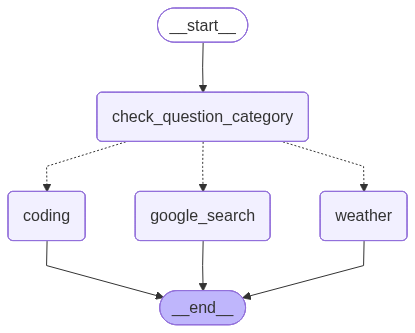

In [26]:
graph

In [32]:
response = graph.invoke({"question":"what is java ?"})

Coding NODE...


In [34]:
#print(response["answer"])
print("Question :", response["question"])
print("Category :", response["category"])
print("Answer :")
print(response["answer"])

Question : what is java ?
Category : coding
Answer :
**Java Overview**

Java is a high-level, object-oriented programming language developed by Sun Microsystems (now owned by Oracle Corporation). It was first released in 1995 and has since become one of the most popular programming languages in the world.

**Key Features of Java**
------------------------

* **Platform Independence**: Java is known for its "write once, run anywhere" (WORA) philosophy, which means that Java code can run on any device that has a Java Virtual Machine (JVM) installed, regardless of the underlying operating system or hardware architecture.
* **Object-Oriented**: Java is an object-oriented language that supports encapsulation, inheritance, and polymorphism, making it easy to write reusable and modular code.
* **Simple and Familiar Syntax**: Java's syntax is based on C++ and is designed to be easy to learn and use, even for developers who are new to programming.
* **Robust Security**: Java has a built-in secu

In [37]:
# ============================================================
# MEDICAL LANGGRAPH PROJECT
# AI Patient Triage Assistant
# 3 Agents + Conditional Edges + Structured Output
# ============================================================

# pip install langgraph langchain langchain-groq python-dotenv pydantic

# ============================================================
# STEP 1: Imports
# ============================================================

from dotenv import load_dotenv
load_dotenv()

from typing import Literal
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

# ============================================================
# STEP 2: LLM
# ============================================================

llm = ChatGroq(model="llama-3.3-70b-versatile")

# ============================================================
# STEP 3: Structured Output Models
# ============================================================

class RouterOutput(BaseModel):
    category: Literal["triage", "report", "medicine"] = Field(
        description="Choose best category"
    )

class FlowState(BaseModel):
    question: str
    category: str = ""
    answer: str = ""

# ============================================================
# STEP 4: Router Node
# ============================================================

def classify_question(state: FlowState) -> FlowState:

    structured_llm = llm.with_structured_output(RouterOutput)

    result = structured_llm.invoke(
        f"""
        Categorize this user question into one category only:

        triage   = symptoms / pain / fever / emergency
        report   = blood test / sugar / cholesterol / reports
        medicine = tablet uses / side effects / medication info

        Question: {state.question}
        """
    )

    state.category = result.category
    return state

# ============================================================
# STEP 5: Route Logic
# ============================================================

def route_logic(state: FlowState) -> Literal["triage", "report", "medicine"]:
    return state.category

# ============================================================
# STEP 6: Agent Nodes
# ============================================================

def triage_node(state: FlowState) -> FlowState:

    prompt = f"""
    You are a medical triage assistant.

    Analyze symptoms and provide:
    1. Severity: Low / Medium / High
    2. Recommended action
    3. Keep concise
    4. Do not diagnose

    Symptoms: {state.question}
    """

    response = llm.invoke(prompt)
    state.answer = response.content
    return state


def report_node(state: FlowState) -> FlowState:

    prompt = f"""
    You are a medical lab report assistant.

    Explain the report in simple language.
    Give general meaning only.
    No diagnosis.

    Query: {state.question}
    """

    response = llm.invoke(prompt)
    state.answer = response.content
    return state


def medicine_node(state: FlowState) -> FlowState:

    prompt = f"""
    You are a medicine information assistant.

    Explain:
    1. Common uses
    2. Common precautions
    3. Keep concise
    4. No prescription advice

    Question: {state.question}
    """

    response = llm.invoke(prompt)
    state.answer = response.content
    return state

# ============================================================
# STEP 7: Safety Check Node
# ============================================================

def safety_node(state: FlowState) -> FlowState:

    disclaimer = """

Important:
This is general AI-generated information, not medical advice.
For emergencies or worsening symptoms, contact a doctor immediately.
"""

    state.answer = state.answer + disclaimer
    return state

# ============================================================
# STEP 8: Build Graph
# ============================================================

graph = StateGraph(FlowState)

# Add Nodes
graph.add_node("router", classify_question)
graph.add_node("triage", triage_node)
graph.add_node("report", report_node)
graph.add_node("medicine", medicine_node)
graph.add_node("safety", safety_node)

# Start
graph.add_edge(START, "router")

# Conditional Edges
graph.add_conditional_edges("router", route_logic)

# Connect to safety
graph.add_edge("triage", "safety")
graph.add_edge("report", "safety")
graph.add_edge("medicine", "safety")

# End
graph.add_edge("safety", END)

# Compile
app = graph.compile()

# ============================================================
# STEP 9: Run Project
# ============================================================

response = app.invoke({
    "question": "I have chest pain and sweating"
})

print("=" * 50)
print("Question :", response["question"])
print("Category :", response["category"])
print("-" * 50)
print(response["answer"])
print("=" * 50)

Question : I have chest pain and sweating
Category : triage
--------------------------------------------------
1. Severity: High
2. Recommended action: Seek immediate medical attention, call emergency services or go to the ER.
3. **Please get help right away**.

Important:
This is general AI-generated information, not medical advice.
For emergencies or worsening symptoms, contact a doctor immediately.



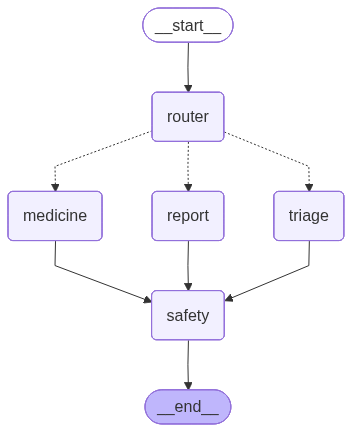

In [36]:
app